In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image

c:\Users\DELL\AppData\Local\Programs\Python\Python313\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.30.2 at tensorflow/core/framework/attr_value.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
c:\Users\DELL\AppData\Local\Programs\Python\Python313\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.30.2 at tensorflow/core/framework/tensor.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
c:\Users\DELL\AppData\Local\Programs\Python\Python313\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.30.2 at tensorflow/core/framework/

In [2]:
model = tf.keras.models.load_model("aqi_model_v2.keras")

In [3]:
img_path = "test/Test Image.jpg"

img = image.load_img(img_path, target_size=(100, 100))
img_array = image.img_to_array(img)

original_img = img_array.copy()

img_array = np.expand_dims(img_array, axis=0) / 255.0

In [4]:
class_names = ["Good", "Moderate", "Severe", "Unhealthy"]

In [5]:
original_pred = model.predict(img_array)
original_class = np.argmax(original_pred)

print("Original:", class_names[original_class])
print(original_pred)

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
Original: Unhealthy
[[0.00917718 0.2962936  0.14013857 0.55439067]]


In [6]:
loss_object = tf.keras.losses.CategoricalCrossentropy()

# Convert label
label = tf.one_hot([original_class], depth=4)

# Enable gradient tracking
img_tensor = tf.convert_to_tensor(img_array)

with tf.GradientTape() as tape:
    tape.watch(img_tensor)
    prediction = model(img_tensor)
    loss = loss_object(label, prediction)

# Get gradient
gradient = tape.gradient(loss, img_tensor)

# Get sign of gradient
signed_grad = tf.sign(gradient)

# Add small noise (epsilon)
epsilon = 0.02
adversarial_img = img_tensor + epsilon * signed_grad
adversarial_img = tf.clip_by_value(adversarial_img, 0, 1)

In [7]:
adv_pred = model.predict(adversarial_img)
adv_class = np.argmax(adv_pred)

print("Adversarial:", class_names[adv_class])
print(adv_pred)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 338ms/step
Adversarial: Unhealthy
[[0.01297081 0.30056065 0.14711013 0.5393584 ]]


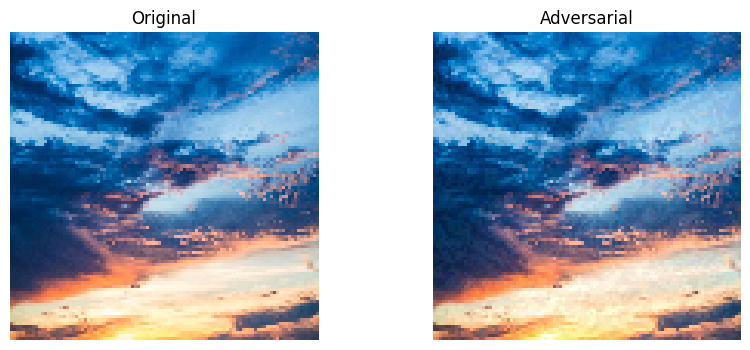

In [8]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(original_img.astype("uint8"))
plt.title("Original")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(adversarial_img[0])
plt.title("Adversarial")
plt.axis("off")

plt.show()

In [9]:
epsilons = [0.0, 0.01, 0.02, 0.05, 0.1, 0.2]

results_adv = []

loss_object = tf.keras.losses.CategoricalCrossentropy()
label = tf.one_hot([original_class], depth=4)

for eps in epsilons:
    
    img_tensor = tf.convert_to_tensor(img_array)
    
    with tf.GradientTape() as tape:
        tape.watch(img_tensor)
        prediction = model(img_tensor)
        loss = loss_object(label, prediction)
    
    gradient = tape.gradient(loss, img_tensor)
    signed_grad = tf.sign(gradient)
    
    adv_img = img_tensor + eps * signed_grad
    adv_img = tf.clip_by_value(adv_img, 0, 1)
    
    pred = model.predict(adv_img)
    pred_class = np.argmax(pred)
    
    results_adv.append(class_names[pred_class])
    
    print(f"Epsilon {eps} → {class_names[pred_class]} | {pred}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 489ms/step
Epsilon 0.0 → Unhealthy | [[0.00917718 0.2962936  0.14013857 0.55439067]]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 274ms/step
Epsilon 0.01 → Unhealthy | [[0.01123105 0.29881114 0.14428425 0.54567355]]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 380ms/step
Epsilon 0.02 → Unhealthy | [[0.01297081 0.30056065 0.14711013 0.5393584 ]]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step
Epsilon 0.05 → Unhealthy | [[0.01643305 0.30331504 0.15149555 0.5287563 ]]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 231ms/step
Epsilon 0.1 → Unhealthy | [[0.02028205 0.30570814 0.15485801 0.5191518 ]]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 191ms/step
Epsilon 0.2 → Unhealthy | [[0.02449663 0.307937   0.15705049 0.5105159 ]]


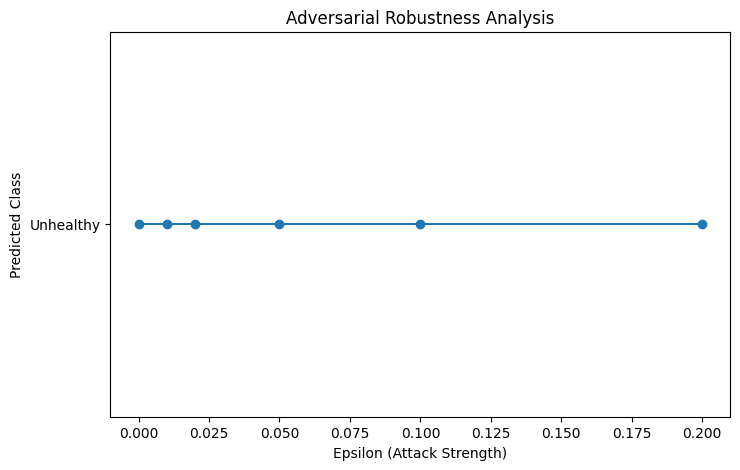

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(epsilons, results_adv, marker='o')

plt.xlabel("Epsilon (Attack Strength)")
plt.ylabel("Predicted Class")
plt.title("Adversarial Robustness Analysis")

plt.show()

In [11]:
confidences = []

for eps in epsilons:
    
    img_tensor = tf.convert_to_tensor(img_array)
    
    with tf.GradientTape() as tape:
        tape.watch(img_tensor)
        prediction = model(img_tensor)
        loss = loss_object(label, prediction)
    
    gradient = tape.gradient(loss, img_tensor)
    signed_grad = tf.sign(gradient)
    
    adv_img = img_tensor + eps * signed_grad
    adv_img = tf.clip_by_value(adv_img, 0, 1)
    
    pred = model.predict(adv_img)
    
    confidence = np.max(pred)   # highest probability
    confidences.append(confidence)
    
    print(f"Epsilon {eps} → Confidence: {confidence}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step
Epsilon 0.0 → Confidence: 0.5543906688690186
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step
Epsilon 0.01 → Confidence: 0.5456735491752625
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step
Epsilon 0.02 → Confidence: 0.539358377456665
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step
Epsilon 0.05 → Confidence: 0.528756320476532
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step
Epsilon 0.1 → Confidence: 0.5191518068313599
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step
Epsilon 0.2 → Confidence: 0.5105159282684326


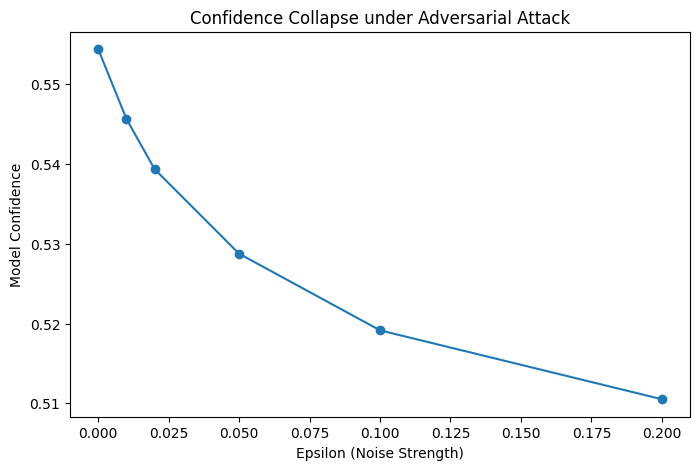

In [12]:
plt.figure(figsize=(8,5))
plt.plot(epsilons, confidences, marker='o')

plt.xlabel("Epsilon (Noise Strength)")
plt.ylabel("Model Confidence")
plt.title("Confidence Collapse under Adversarial Attack")

plt.show()